In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)

df_d = diabetes.frame

In [115]:
df_d.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [116]:
df_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [117]:
# check for missing values

df_d.isna().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [118]:
# check for duplicated values

df_d.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
437    False
438    False
439    False
440    False
441    False
Length: 442, dtype: bool

In [119]:
# check for data stat

df_d.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [120]:
df_d.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

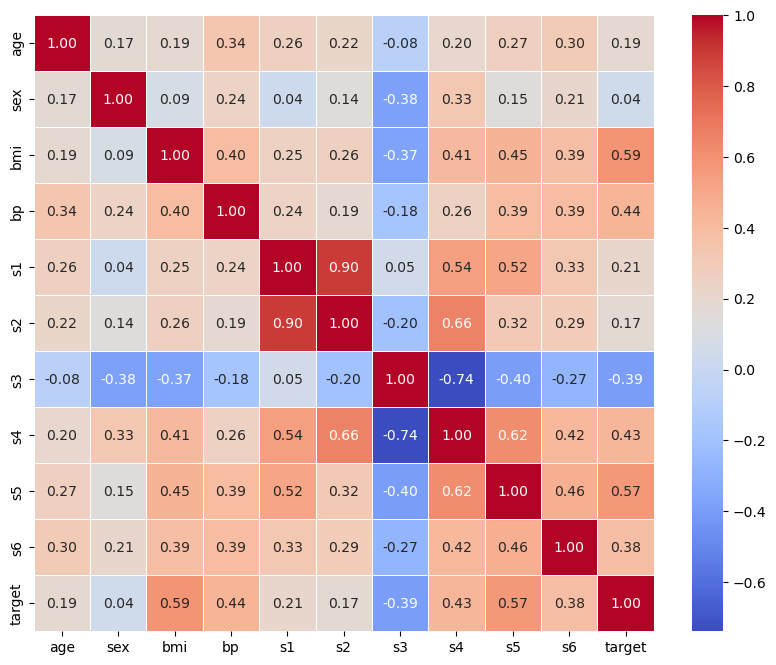

In [121]:
# check for correlation

corr_col = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

corr_d = df_d[corr_col].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_d, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5)
plt.show()

In [122]:
# Feature Engineering

In [123]:
# create new meaningful features
df_d['bmi_bp_interaction'] = df_d['bmi'] * df_d['bp']

In [124]:
X= df_d.drop('target', axis = 1)
y = df_d['target']

In [125]:
# Split Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [126]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_trained_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [127]:
# Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_trained_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [128]:
y_pred_lr = lr.predict(X_test_scaled)

In [129]:
# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print('Linear Regression RMSE:', rmse_lr)
print('Linear Regression R2:', r2_lr)

Linear Regression RMSE: 52.54120333846574
Linear Regression R2: 0.47895451484059104


In [130]:
# Ridge
from sklearn.linear_model import Ridge

rd = Ridge(alpha=1.0)

rd.fit(X_trained_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [131]:
y_rd_pred = rd.predict(X_test_scaled)

In [132]:
# Evaluation

rmse_rd = np.sqrt(mean_squared_error(y_test, y_rd_pred))
r2_rd = r2_score(y_test, y_rd_pred)

print('Ridge  RMSE:', rmse_rd)
print('Ridge  R2:', r2_rd)

Ridge  RMSE: 52.46881507711167
Ridge  R2: 0.4803892590719149


In [133]:
# Compare coefficient
coef_df = pd.DataFrame({'Feature': X.columns,
                       'Linear': lr.coef_,
                       'Ridge': rd.coef_})
print(coef_df)

               Feature     Linear      Ridge
0                  age   2.514743   2.560288
1                  sex -11.836468 -11.766994
2                  bmi  24.707744  24.856262
3                   bp  15.479697  15.400445
4                   s1 -46.283163 -35.934363
5                   s2  27.462968  19.405801
6                   s3   8.454963   3.903219
7                   s4  13.563946  12.118981
8                   s5  35.831232  31.827384
9                   s6   2.534707   2.641681
10  bmi_bp_interaction   7.009152   6.936879


In [134]:
# Lasso 

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_trained_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [135]:
y_pred_lasso=lasso.predict(X_test_scaled)

In [136]:
# Evaluation

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_r2 = r2_score(y_test, y_pred_lasso)

print('Lasso RMSE:', lasso_rmse)
print('Lasso R2:', lasso_r2)

Lasso RMSE: 52.40748013601328
Lasso R2: 0.48160337706906653


In [137]:
lasso_coef = lasso.coef_

lasso_coef

array([  2.46990107, -11.6318348 ,  24.95067243,  15.33325563,
       -31.14210311,  16.01900812,   1.30448516,  10.64947622,
        30.28439339,   2.57162575,   6.81086194])

In [138]:
# Elastic Net

from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic.fit(X_trained_scaled, y_train)

,alpha,0.1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [139]:
#predict

y_pred_elastic = elastic.predict(X_test_scaled)

In [140]:
# Evaluation

elastic_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
elastic_r2 = r2_score(y_test, y_pred_elastic)

print('Elastic RMSE:', elastic_rmse)
print('Elastic R2:', elastic_r2)

Elastic RMSE: 52.30647957451366
Elastic R2: 0.48359957673068865


In [141]:
# Compare coefficient
coef_df = pd.DataFrame({'Feature': X.columns,
                       'Linear': lr.coef_,
                       'Ridge': rd.coef_,
                        'Lasso': lasso.coef_,
                        'elastic': elastic.coef_
                       })
print(coef_df)

               Feature     Linear      Ridge      Lasso    elastic
0                  age   2.514743   2.560288   2.469901   2.585624
1                  sex -11.836468 -11.766994 -11.631835 -10.905470
2                  bmi  24.707744  24.856262  24.950672  24.461521
3                   bp  15.479697  15.400445  15.333256  14.776467
4                   s1 -46.283163 -35.934363 -31.142103  -8.737440
5                   s2  27.462968  19.405801  16.019008  -0.970639
6                   s3   8.454963   3.903219   1.304485  -7.833363
7                   s4  13.563946  12.118981  10.649476   7.949944
8                   s5  35.831232  31.827384  30.284393  20.891889
9                   s6   2.534707   2.641681   2.571626   3.311359
10  bmi_bp_interaction   7.009152   6.936879   6.810862   6.686156


In [142]:
# Diagnose Problem using Variance_inflation_factor

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df['Features'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df)

              Features        VIF
0                  age   1.229932
1                  sex   1.278828
2                  bmi   1.516704
3                   bp   1.485174
4                   s1  59.256326
5                   s2  39.359636
6                   s3  15.402251
7                   s4   8.894192
8                   s5  10.085319
9                   s6   1.485017
10  bmi_bp_interaction   1.066671


### Dropping the S2 column due to its high VIF

In [143]:
#  dropping s2 with 39.359636 vif to check its effect on the evaluation of our model

Xn = df_d.drop(['s2', 'target'], axis=1)
yn = df_d['target']

In [144]:
from sklearn.model_selection import train_test_split

Xn_train, Xn_test, yn_train, yn_test = train_test_split(Xn, yn, test_size=0.2, random_state=42)

In [145]:
# preprocess to standardize the X
from sklearn.preprocessing import StandardScaler

scaler_n = StandardScaler()

Xn_train_scaled = scaler_n.fit_transform(Xn_train)

Xn_test_scaled = scaler_n.transform(Xn_test)

In [146]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr_n = LinearRegression()

lr_n.fit(Xn_train_scaled, yn_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
y_pred_lrn = lr_n.predict(Xn_test_scaled)

In [148]:
# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

rmse_lrn = np.sqrt(mean_squared_error(yn_test, y_pred_lrn))
r2_lrn = r2_score(yn_test, y_pred_lrn)

print('Linear Regression RMSE:', rmse_lrn)
print('Linear Regression R2:', r2_lrn)

Linear Regression RMSE: 52.608691030876315
Linear Regression R2: 0.4776151187520986


In [149]:
lr_n_coeff = lr_n.coef_

print(lr_n_coeff)

[  2.74862635 -11.7896986   25.44663577  15.38104204 -13.6631796
  -4.33307783  11.73685274  22.90563773   2.75790813   6.66939987]


In [150]:
# Ridge Regression
from sklearn.linear_model import Ridge

rd_n = Ridge(alpha=1.0)

rd_n.fit(Xn_train_scaled, yn_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [151]:
y_pred_rdn = rd_n.predict(Xn_test_scaled)

In [152]:
# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

rmse_rdn = np.sqrt(mean_squared_error(yn_test, y_pred_rdn))
r2_rdn = r2_score(yn_test, y_pred_rdn)

print('Ridge RMSE:', rmse_rdn)
print('Ridge R2:', r2_rdn)

Ridge RMSE: 52.57731766387398
Ridge R2: 0.47823798487804814


In [153]:
rd_n_coeff = rd_n.coef_

print(rd_n_coeff)

[  2.73783668 -11.73878536  25.3839452   15.34147486 -13.31515434
  -4.6723684   11.33415916  22.80084884   2.79573904   6.6777556 ]


In [154]:
# Lasso Regression
from sklearn.linear_model import Lasso

lasso_n = Lasso(alpha=0.1)

lasso_n.fit(Xn_train_scaled, yn_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [155]:
y_pred_lasso_n = lasso_n.predict(Xn_test_scaled)

In [156]:
# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

rmse_lasso_n = np.sqrt(mean_squared_error(yn_test, y_pred_lasso_n))
r2_lasso_n = r2_score(yn_test, y_pred_lasso_n)

print('Ridge RMSE:', rmse_lasso_n)
print('Ridge R2:', r2_lasso_n)

Ridge RMSE: 52.5287144409099
Ridge R2: 0.4792021875199767


In [157]:
lasso_n.coef_

array([  2.60889032, -11.56779728,  25.4530572 ,  15.29262771,
       -12.97829273,  -4.86297119,  10.90915495,  22.82127029,
         2.70940664,   6.59588898])

In [158]:
# Elastic Net

from sklearn.linear_model import ElasticNet

elastic_n = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic_n.fit(Xn_train_scaled, yn_train)

,alpha,0.1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [159]:
y_pred_elastic_n = elastic_n.predict(Xn_test_scaled)

In [160]:
# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

rmse_elastic_n = np.sqrt(mean_squared_error(yn_test, y_pred_elastic_n))
r2_elastic_n = r2_score(yn_test, y_pred_elastic_n)

print('Ridge RMSE:', rmse_elastic_n)
print('Ridge R2:', r2_elastic_n)

Ridge RMSE: 52.28559861888919
Ridge R2: 0.4840117926593924


In [161]:
coef_n = pd.DataFrame({
    'Features': Xn.columns,
    'Linear': lr_n.coef_,
    'Ridge': rd_n.coef_,
    'Lasso': lasso_n.coef_,
    'Elastic': elastic_n.coef_
})

print(coef_n)
print('='*70)
print(coef_df)

             Features     Linear      Ridge      Lasso    Elastic
0                 age   2.748626   2.737837   2.608890   2.570933
1                 sex -11.789699 -11.738785 -11.567797 -10.907509
2                 bmi  25.446636  25.383945  25.453057  24.432883
3                  bp  15.381042  15.341475  15.292628  14.776771
4                  s1 -13.663180 -13.315154 -12.978293  -9.657770
5                  s3  -4.333078  -4.672368  -4.862971  -7.608791
6                  s4  11.736853  11.334159  10.909155   7.780605
7                  s5  22.905638  22.800849  22.821270  21.269214
8                  s6   2.757908   2.795739   2.709407   3.304370
9  bmi_bp_interaction   6.669400   6.677756   6.595889   6.710979
               Feature     Linear      Ridge      Lasso    elastic
0                  age   2.514743   2.560288   2.469901   2.585624
1                  sex -11.836468 -11.766994 -11.631835 -10.905470
2                  bmi  24.707744  24.856262  24.950672  24.461521
3     

In [162]:
intercept_n = pd.DataFrame({
    'Features': Xn.columns,
    'Linear': lr_n.intercept_,
    'Ridge': rd_n.intercept_,
    'Lasso': lasso_n.intercept_,
    'Elastic': elastic_n.intercept_
})

intercept_df = pd.DataFrame({'Feature': X.columns,
                       'Linear': lr.intercept_,
                       'Ridge': rd.intercept_,
                        'Lasso': lasso.intercept_,
                        'elastic': elastic.intercept_
                       })
print(intercept_df)
print('=' * 70)
print(intercept_n)

               Feature      Linear       Ridge       Lasso     elastic
0                  age  153.736544  153.736544  153.736544  153.736544
1                  sex  153.736544  153.736544  153.736544  153.736544
2                  bmi  153.736544  153.736544  153.736544  153.736544
3                   bp  153.736544  153.736544  153.736544  153.736544
4                   s1  153.736544  153.736544  153.736544  153.736544
5                   s2  153.736544  153.736544  153.736544  153.736544
6                   s3  153.736544  153.736544  153.736544  153.736544
7                   s4  153.736544  153.736544  153.736544  153.736544
8                   s5  153.736544  153.736544  153.736544  153.736544
9                   s6  153.736544  153.736544  153.736544  153.736544
10  bmi_bp_interaction  153.736544  153.736544  153.736544  153.736544
             Features      Linear       Ridge       Lasso     Elastic
0                 age  153.736544  153.736544  153.736544  153.736544
1       

### Hyperparameter tuning

In [163]:
# Ridge Grid Search

from sklearn.model_selection import GridSearchCV

params = {'alpha': [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(Ridge(), param_grid=params, cv=5, scoring='neg_root_mean_squared_error')

grid.fit(X_trained_scaled, y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.01, 0.1, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,10


In [164]:
# best parameter
print(grid.best_params_)

{'alpha': 10}


In [165]:
# best model
best_model_ridge = grid.best_estimator_
print(best_model_ridge)

Ridge(alpha=10)


In [166]:
y_ridge_gr_pred = best_model_ridge.predict(X_test_scaled)

In [167]:
print('Tune Elastic RMSE:',np.sqrt(mean_squared_error(y_test, y_ridge_gr_pred)))
print('Tune Elastic R2:',r2_score(y_test, y_ridge_gr_pred))

Tune Elastic RMSE: 52.35965645755582
Tune Elastic R2: 0.48254905588144903


In [168]:
from sklearn.model_selection import GridSearchCV

params2 = {'alpha': [0.001, 0.01, 0.1, 1]}

grid = GridSearchCV(Lasso(), param_grid=params2, cv=5, scoring='neg_root_mean_squared_error')

grid.fit(X_trained_scaled, y_train)

,estimator,Lasso()
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.1


In [169]:
# Best Parameter
print(grid.best_params_)

{'alpha': 0.1}


In [170]:
# best estimator
best_model_Lasso = grid.best_estimator_
print(best_model_Lasso)

Lasso(alpha=0.1)


In [171]:
y_lasso_gr_pred = best_model_Lasso.predict(X_test_scaled)

In [172]:
print('Tune Elastic RMSE:',np.sqrt(mean_squared_error(y_test, y_lasso_gr_pred)))
print('Tune Elastic R2:',r2_score(y_test, y_lasso_gr_pred))

Tune Elastic RMSE: 52.40748013601328
Tune Elastic R2: 0.48160337706906653


In [173]:
params2 = {'alpha': [0.001, 0.01, 0.1, 1],
          'l1_ratio': [0.2, 0.5, 0.8]}

grid = GridSearchCV(ElasticNet(), param_grid=params2, cv=5, scoring='neg_root_mean_squared_error')

grid.fit(X_trained_scaled, y_train)

,estimator,ElasticNet()
,param_grid,"{'alpha': [0.001, 0.01, ...], 'l1_ratio': [0.2, 0.5, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.1


In [174]:
# best parameter
print(grid.best_params_)

{'alpha': 0.1, 'l1_ratio': 0.2}


In [175]:
# best model

best_model_Elastic = grid.best_estimator_
print(best_model_Elastic)

ElasticNet(alpha=0.1, l1_ratio=0.2)


In [176]:
print(best_model_Elastic.coef_)

[  2.61571833 -10.55207284  23.95730369  14.51830884  -6.42363478
  -2.4728758   -8.63473059   7.6794609   19.64290473   3.6110498
   6.66251305]


In [177]:
y_el_gr_pred = best_model_Elastic.predict(X_test_scaled)

In [178]:
print('Tune Elastic RMSE:',np.sqrt(mean_squared_error(y_test, y_el_gr_pred)))
print('Tune Elastic R2:',r2_score(y_test, y_el_gr_pred))

Tune Elastic RMSE: 52.29728172626521
Tune Elastic R2: 0.4837811739306802


# Hyperparameter Tuning 2

In [179]:
# Ridge Grid Search

from sklearn.model_selection import GridSearchCV

params = {'alpha': [0.01, 0.1, 1, 10, 100]}

grid2 = GridSearchCV(Ridge(), param_grid=params, cv=5, scoring='neg_root_mean_squared_error')

grid2.fit(Xn_train_scaled, yn_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.01, 0.1, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,10


In [180]:
# best parameter
print('Best parameter:',grid2.best_params_)

# best estimator
best_estimator_ridge2 = grid2.best_estimator_
print('Best Estimator:',best_estimator_ridge2)

Best parameter: {'alpha': 10}
Best Estimator: Ridge(alpha=10)


In [181]:
y_ridge_gr2_pred = best_estimator_ridge2.predict(Xn_test_scaled)

print('Tune Ridge2 RMSE:',np.sqrt(mean_squared_error(yn_test, y_ridge_gr2_pred)))
print('Tune Ridge2 R2:',r2_score(yn_test, y_ridge_gr2_pred))

Tune Ridge2 RMSE: 52.39230008233523
Tune Ridge2 R2: 0.48190364523137563


In [182]:
# Lasso
params2 = {'alpha': [0.001, 0.01, 0.1, 1]}

grid2 = GridSearchCV(Lasso(), param_grid=params2, cv=5, scoring='neg_root_mean_squared_error')

grid2.fit(Xn_train_scaled, yn_train)

,estimator,Lasso()
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1


In [183]:
# best parameter
print('Best parameter:',grid2.best_params_)

# best estimator
best_estimator_lasso2 = grid2.best_estimator_
print('Best Estimator:',best_estimator_lasso2)

y_lasso_gr2_pred = best_estimator_lasso2.predict(Xn_test_scaled)

print('Tune Lasso2 RMSE:',np.sqrt(mean_squared_error(yn_test, y_lasso_gr2_pred)))
print('Tune Lasso2 R2:',r2_score(yn_test, y_lasso_gr2_pred))

Best parameter: {'alpha': 1}
Best Estimator: Lasso(alpha=1)
Tune Lasso2 RMSE: 51.98697874245649
Tune Lasso2 R2: 0.4898889108781527


In [184]:
# Elastic
params2 = {'alpha': [0.001, 0.01, 0.1, 1]}

grid2 = GridSearchCV(ElasticNet(), param_grid=params2, cv=5, scoring='neg_root_mean_squared_error')

grid2.fit(Xn_train_scaled, yn_train)

,estimator,ElasticNet()
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.1


In [185]:
# best parameter
print('Best parameter:',grid2.best_params_)

# best estimator
best_estimator_en2 = grid2.best_estimator_
print('Best Estimator:',best_estimator_en2)

y_en_gr2_pred = best_estimator_en2.predict(Xn_test_scaled)

print('Tune Lasso2 RMSE:',np.sqrt(mean_squared_error(yn_test, y_en_gr2_pred)))
print('Tune Lasso2 R2:',r2_score(yn_test, y_en_gr2_pred))

Best parameter: {'alpha': 0.1}
Best Estimator: ElasticNet(alpha=0.1)
Tune Lasso2 RMSE: 52.28559861888919
Tune Lasso2 R2: 0.4840117926593924


In [191]:
coef_grid = pd.DataFrame({
    'Features': X.columns,
    'Ridge': best_model_ridge.coef_,
    'Lasso': best_model_Lasso.coef_,
    'Elastic': best_model_Elastic.coef_
})

coef_grid2 = pd.DataFrame({
    'Features': Xn.columns,
    'Ridge': best_estimator_ridge2.coef_,
    'Lasso': best_estimator_lasso2.coef_,
    'Elastic': best_estimator_en2.coef_
})



              Features      Ridge      Lasso    Elastic
0                  age   2.644752   2.469901   2.615718
1                  sex -11.324721 -11.631835 -10.552073
2                  bmi  24.798465  24.950672  23.957304
3                   bp  15.035829  15.333256  14.518309
4                   s1 -12.978167 -31.142103  -6.423635
5                   s2   1.850848  16.019008  -2.472876
6                   s3  -6.080716   1.304485  -8.634731
7                   s4   8.812993  10.649476   7.679461
8                   s5  22.721770  30.284393  19.642905
9                   s6   3.090058   2.571626   3.611050
10  bmi_bp_interaction   6.766519   6.810862   6.662513
             Features      Ridge      Lasso    Elastic
0                 age   2.669005   1.354439   2.570933
1                 sex -11.322734  -9.569467 -10.907509
2                 bmi  24.851570  25.519074  24.432883
3                  bp  15.034594  14.501590  14.776771
4                  s1 -11.081670  -6.937083  -9.65777

In [192]:
print(coef_df)
print('='*70)
print(coef_n)


print('===== Hypertuning paramters coefficient =======')
print(coef_grid)
print('='*70)
print(coef_grid2)

               Feature     Linear      Ridge      Lasso    elastic
0                  age   2.514743   2.560288   2.469901   2.585624
1                  sex -11.836468 -11.766994 -11.631835 -10.905470
2                  bmi  24.707744  24.856262  24.950672  24.461521
3                   bp  15.479697  15.400445  15.333256  14.776467
4                   s1 -46.283163 -35.934363 -31.142103  -8.737440
5                   s2  27.462968  19.405801  16.019008  -0.970639
6                   s3   8.454963   3.903219   1.304485  -7.833363
7                   s4  13.563946  12.118981  10.649476   7.949944
8                   s5  35.831232  31.827384  30.284393  20.891889
9                   s6   2.534707   2.641681   2.571626   3.311359
10  bmi_bp_interaction   7.009152   6.936879   6.810862   6.686156
             Features     Linear      Ridge      Lasso    Elastic
0                 age   2.748626   2.737837   2.608890   2.570933
1                 sex -11.789699 -11.738785 -11.567797 -10.90750